# Same experiments, new potential: $U(x)=2\log\bigl(1+\lVert x\rVert^2\bigr)$

This is `anchored_langevin_multivariate.ipynb` with the potential replaced and **nothing else changed** —
same experiment set ($J=0$ vs constant skew $J_a$, invariance check, sweep over $a$, fixed-physical-time
control, dimension scan), same protocol, same plots.

$$\pi(x)\;\propto\;e^{-U(x)}=\bigl(1+\lVert x\rVert^2\bigr)^{-2}.$$

Three consequences follow from the swap itself, and they are reported rather than worked around:

1. **The anchor becomes exact.** The previous notebook built $U_0$ by smoothing a non-differentiable $U$.
   This $U$ is already $C^\infty$, with $\nabla U(x)=\dfrac{4x}{1+\lVert x\rVert^2}$, so the same recipe
   returns $U_0=U$, giving $\Delta=U-U_0\equiv0$ and $e^{\Delta}\equiv1$. The anchored update therefore
   reduces exactly to Langevin plus the skew term. No new anchor is invented here.
2. **The target is isotropic**, depending on $x$ only through $\lVert x\rVert$, so the previous notebook's
   two shaped targets (elliptical and correlated $\ell_1$, both built from $\Sigma$) collapse to one.
3. **The coefficient 2 sits outside the range the formula asks for.** Writing the exponent as $p$, the
   target is the multivariate $t$ with $\nu=2p-d$, and the stated condition $p>1+\frac d2$ is exactly
   $\nu>2$, i.e. finite variance. With $p=2$ and $d=3$ we get $\nu=1$ — a Cauchy-like law with **no finite
   mean** — so $W_1$ has no finite population value and the curves below are dominated by rare enormous
   draws. The next cells quantify that before any experiment is run. The target also only exists at all
   while $2p>d$, i.e. $d\le3$ here, which caps the dimension scan.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, ks_2samp

In [2]:
# -----------------------------
# Settings (unchanged from the multivariate notebook)
# -----------------------------
d        = 3
P_EXP    = 2.0        # the coefficient in U(x) = 2 log(1 + ||x||^2)
NU       = 2 * P_EXP - d
N        = 5000
max_iter = 2000
eta      = 5e-3
x_start  = 0.5
SEED     = 1006
A_MAIN   = 2.0

print("U(x) = {} * log(1 + ||x||^2),  d = {}  ->  nu = 2p - d = {}".format(P_EXP, d, NU))
print("normalizable (needs 2p > d)      : {}".format(2 * P_EXP > d))
print("finite mean  (needs nu > 1)      : {}".format(NU > 1))
print("finite variance (needs nu > 2, i.e. p > 1 + d/2 = {}) : {}".format(1 + d / 2, NU > 2))

U(x) = 2.0 * log(1 + ||x||^2),  d = 3  ->  nu = 2p - d = 1.0
normalizable (needs 2p > d)      : True
finite mean  (needs nu > 1)      : False
finite variance (needs nu > 2, i.e. p > 1 + d/2 = 2.5) : False


In [3]:
# -----------------------------
# Target. pi ~ (1+||x||^2)^{-p} is the multivariate t with nu = 2p - d:
#   X = Z / sqrt(G),  Z ~ N(0, I_d),  G ~ chi2_nu
# -----------------------------
def sample_target(n, rng, p=P_EXP, dim=d):
    nu = 2 * p - dim
    return rng.normal(size=(n, dim)) / np.sqrt(rng.chisquare(nu, size=n))[:, None]

def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

# U = p*log(1+|x|^2); the anchor recipe returns U0 = U, so Delta = 0 and grad U0 = grad U.
@torch.no_grad()
def grad_U(x, p=P_EXP):
    return 2 * p * x / (1 + torch.sum(x * x, dim=1, keepdim=True))

def run_chain(a, eta=eta, n_steps=max_iter, N=N, ref=None, p=P_EXP, dim=d, seed=SEED, track=True):
    Mj = (torch.eye(dim) + J_fun(dim, a)).T
    torch.manual_seed(seed)
    x = torch.full((N, dim), x_start)
    W = []
    for _ in range(n_steps):
        x = x - eta * (grad_U(x, p) @ Mj) + np.sqrt(2 * eta) * torch.randn_like(x)
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(dim)])
    return x.numpy(), (np.array(W) if track else None)

In [4]:
# -----------------------------
# How badly does nu = 1 break the yardstick? Compare independent exact samples
# against each other: this is the floor every W1 curve is measured against.
# -----------------------------
rng = np.random.default_rng(SEED)
ref = sample_target(N, rng)

reps = [ [wasserstein_distance(ref[:, i], sample_target(N, rng)[:, i]) for i in range(d)] for _ in range(12) ]
reps = np.array(reps)
floor = reps.mean(axis=0)

print("sampling floor, 12 independent replicates (exact draws vs exact draws):")
print("  mean   :", np.round(floor, 3))
print("  min    :", np.round(reps.min(axis=0), 3))
print("  max    :", np.round(reps.max(axis=0), 3))
print("  max/min:", np.round(reps.max(axis=0) / reps.min(axis=0), 1))
print("\nsample |x| quantiles: q50 = {:.2f}, q99 = {:.1f}, max = {:.0f}".format(
    *[np.quantile(np.abs(ref[:, 0]), q) for q in (0.5, 0.99)], np.abs(ref[:, 0]).max()))
print("\nThe floor is not a stable number: with no finite mean, W1 between two exact samples")
print("fluctuates by an order of magnitude. Every comparison below inherits that noise.")

sampling floor, 12 independent replicates (exact draws vs exact draws):
  mean   : [5.699 2.428 2.444]
  min    : [1.293 1.202 1.127]
  max    : [31.386  7.12   9.822]
  max/min: [24.3  5.9  8.7]

sample |x| quantiles: q50 = 1.01, q99 = 53.1, max = 1793

The floor is not a stable number: with no finite mean, W1 between two exact samples
fluctuates by an order of magnitude. Every comparison below inherits that noise.


## Experiment 1 — $J_a$ vs $J=0$

In [5]:
COLORS = {0.0: "#C44E52", A_MAIN: "#55A868"}
exp1 = {}
for a in [0.0, A_MAIN]:
    xf, W = run_chain(a, ref=ref)
    exp1[a] = {"x": xf, "W1": W}
    print("a = {:<5} W1 (mean of last 100) = {}".format(a, np.round(W[-100:].mean(axis=0), 3)))

a = 0.0   W1 (mean of last 100) = [3.869 3.543 4.053]


a = 2.0   W1 (mean of last 100) = [3.846 3.481 4.03 ]


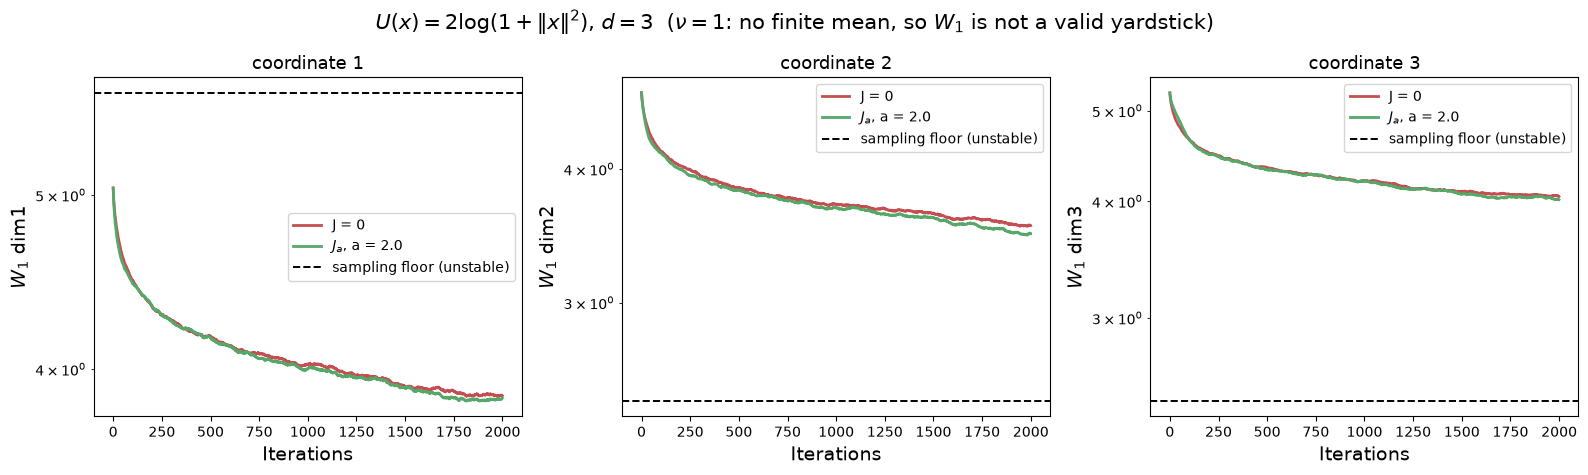

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for a in [0.0, A_MAIN]:
        ax.plot(exp1[a]["W1"][:, i], linewidth=2, color=COLORS[a],
                label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
    ax.axhline(floor[i], color="k", linestyle="--", linewidth=1.4, label="sampling floor (unstable)")
    ax.set_yscale("log")
    ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13)
    ax.legend(fontsize=10)
fig.suptitle(r"$U(x)=2\log(1+\|x\|^2)$, $d=3$  ($\nu=1$: no finite mean, so $W_1$ is not a valid yardstick)",
             fontsize=15)
plt.tight_layout()
plt.savefig("figures/log2_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

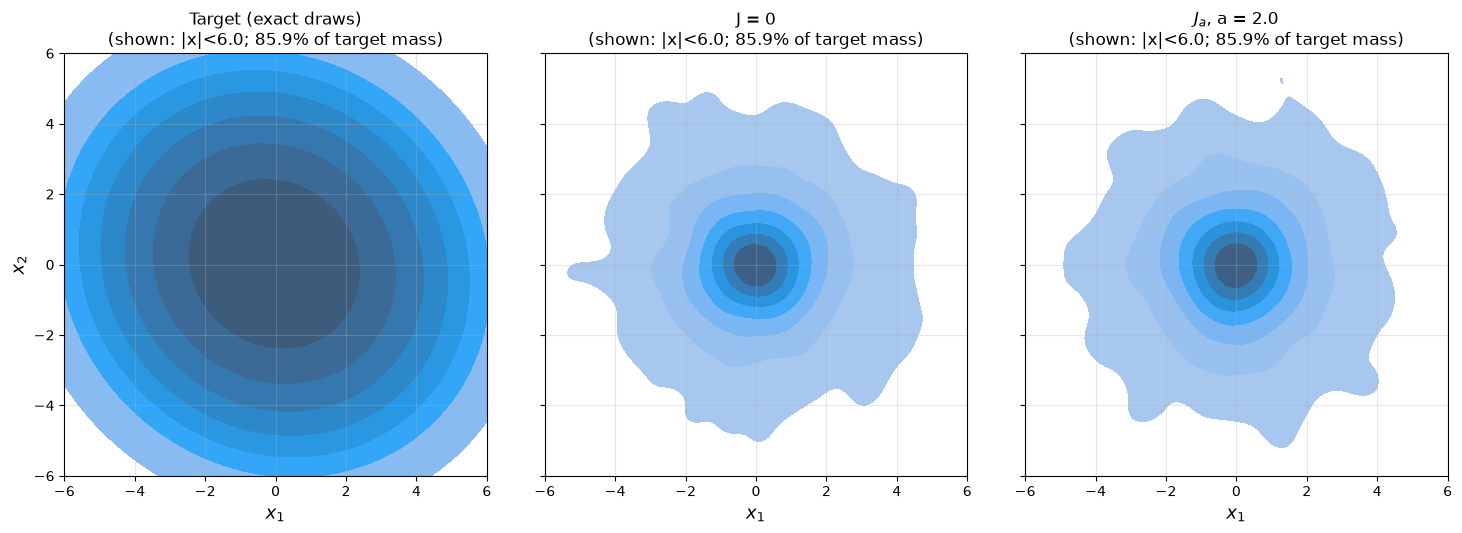

In [7]:
# 2D contours, as in the multivariate notebook. Clipped to the bulk: the raw range is enormous.
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
panels = [("Target (exact draws)", ref), ("J = 0", exp1[0.0]["x"]), ("$J_a$, a = {}".format(A_MAIN), exp1[A_MAIN]["x"])]
lim = 6.0
for ax, (name, X) in zip(axes, panels):
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax, clip=((-lim, lim), (-lim, lim)))
    ax.set_title("{}\n(shown: |x|<{}; {:.1%} of target mass)".format(
        name, lim, np.mean(np.all(np.abs(ref[:, :2]) < lim, axis=1))), fontsize=12)
    ax.set_xlabel("$x_1$", fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")
axes[0].set_ylabel("$x_2$", fontsize=13)
plt.tight_layout()
plt.savefig("figures/log2_density.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# Invariance check. KS is bounded and distribution-free, so unlike W1 it stays meaningful here.
print("{:<10}{:>12}{:>12}{:>12}{:>16}".format("a", "KS dim1", "KS dim2", "KS dim3", "q99(|x1|)"))
print("-" * 64)
for a in [0.0, A_MAIN]:
    X = exp1[a]["x"]
    ks = [ks_2samp(ref[:, i], X[:, i]).statistic for i in range(d)]
    print("{:<10}".format(a) + "".join("{:>12.4f}".format(v) for v in ks)
          + "{:>16.2f}".format(np.quantile(np.abs(X[:, 0]), 0.99)))
print("{:<10}{:>12}{:>12}{:>12}{:>16.2f}".format("target", "-", "-", "-", np.quantile(np.abs(ref[:, 0]), 0.99)))

a              KS dim1     KS dim2     KS dim3       q99(|x1|)
----------------------------------------------------------------
0.0             0.0702      0.0664      0.0636            5.99
2.0             0.0632      0.0622      0.0600            6.14
target               -           -           -           53.13


## Experiment 2 — sweep over the skew strength $a$

In [9]:
A_SWEEP = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0]
sweep = {}
for a in A_SWEEP:
    _, W = run_chain(a, ref=ref)
    sweep[a] = W[-100:].mean(axis=0)
    print("a = {:<5} {}".format(a, np.round(sweep[a], 3)))

a = 0.0   [3.869 3.543 4.053]


a = 0.5   [3.883 3.525 4.066]


a = 1.0   [3.879 3.522 4.059]


a = 2.0   [3.846 3.481 4.03 ]


a = 4.0   [3.793 3.424 3.985]


a = 8.0   [3.616 3.262 3.806]


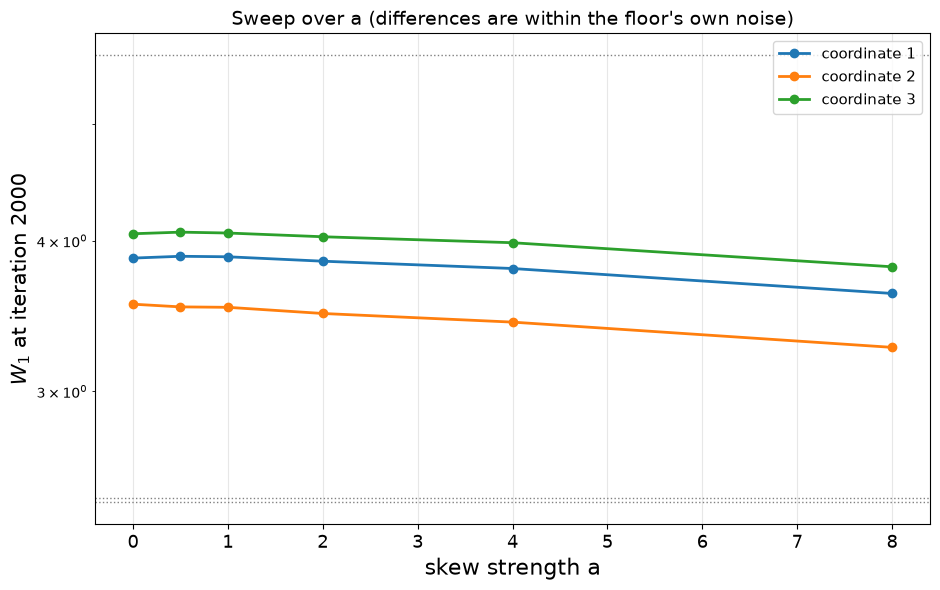

In [10]:
plt.figure(figsize=(9.5, 6))
for i in range(d):
    plt.plot(A_SWEEP, [sweep[a][i] for a in A_SWEEP], marker="o", linewidth=2, label="coordinate {}".format(i + 1))
    plt.axhline(floor[i], linestyle=":", linewidth=1, color="gray")
plt.yscale("log")
plt.xlabel("skew strength a", fontsize=16)
plt.ylabel("$W_1$ at iteration {}".format(max_iter), fontsize=15)
plt.title("Sweep over a (differences are within the floor's own noise)", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/log2_sweep_a.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — fixed-physical-time control

In [11]:
print("W1 at fixed physical time T = 10")
print("{:<12}{:<8}{:>30}".format("eta", "a", "W1 (dim1, dim2, dim3)"))
print("-" * 52)
control = {}
for eta_r, n_r in [(5e-3, 2000), (2.5e-3, 4000), (1.25e-3, 8000)]:
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain(a, eta=eta_r, n_steps=n_r, ref=ref, track=False)
        w = [wasserstein_distance(ref[:, i], xf[:, i]) for i in range(d)]
        control[(eta_r, a)] = w
        print("{:<12}{:<8}{:>30}".format(eta_r, a, np.array2string(np.round(w, 3))))

W1 at fixed physical time T = 10
eta         a                W1 (dim1, dim2, dim3)
----------------------------------------------------


0.005       0.0                [3.865 3.54  4.046]


0.005       2.0                [3.853 3.478 4.014]


0.0025      0.0                [3.859 3.54  4.053]


0.0025      2.0                [3.844 3.541 4.028]


0.00125     0.0                [3.847 3.545 4.097]


0.00125     2.0                [3.874 3.532 4.062]


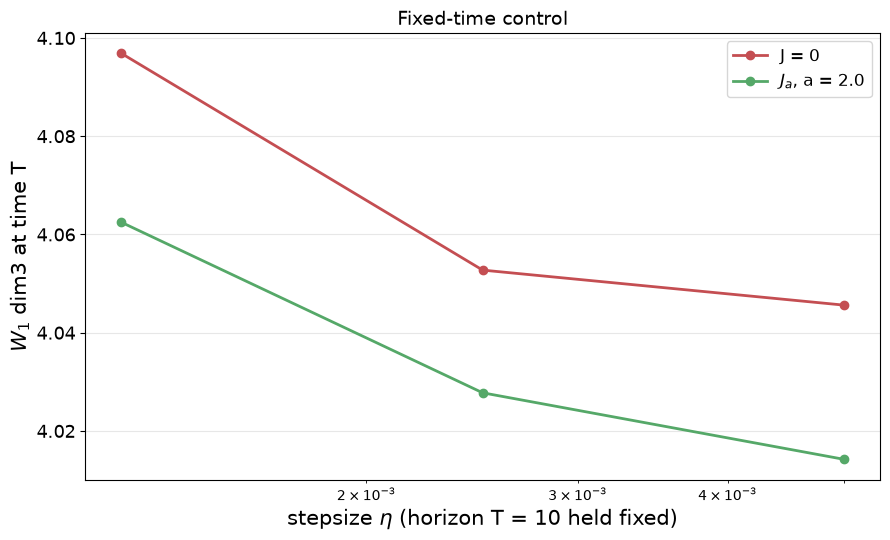

In [12]:
etas = [5e-3, 2.5e-3, 1.25e-3]
plt.figure(figsize=(9, 5.5))
for a in [0.0, A_MAIN]:
    plt.plot(etas, [control[(e, a)][2] for e in etas], marker="o", linewidth=2, color=COLORS[a],
             label="J = 0" if a == 0 else "$J_a$, a = {}".format(a))
plt.xscale("log")
plt.xlabel(r"stepsize $\eta$ (horizon T = 10 held fixed)", fontsize=15)
plt.ylabel("$W_1$ dim3 at time T", fontsize=15)
plt.title("Fixed-time control", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/log2_control.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 4 — dimension scan

The multivariate notebook scanned $d\in\{2,3,5,10\}$. With the coefficient fixed at 2 the target is
normalizable only while $2p>d$, i.e. $d\le3$, and $d=1$ makes the skew matrix identically zero. That
leaves $d\in\{2,3\}$ — the scan cannot be run further without changing the coefficient.

In [13]:
print("{:<6}{:<8}{:<14}{:>34}".format("d", "nu", "finite mean", "W1 mean over coords: a=0 / a=2"))
print("-" * 64)
for dim in [2, 3]:
    nu = 2 * P_EXP - dim
    rng_d = np.random.default_rng(SEED)
    ref_d = sample_target(N, rng_d, dim=dim)
    out = []
    for a in [0.0, A_MAIN]:
        xf, _ = run_chain(a, ref=ref_d, dim=dim, track=False)
        out.append(np.mean([wasserstein_distance(ref_d[:, i], xf[:, i]) for i in range(dim)]))
    print("{:<6}{:<8}{:<14}{:>34}".format(dim, nu, str(nu > 1), "{:.3f}  /  {:.3f}".format(*out)))
print("\nd >= 4 would need 2p > d to fail -> the target is not normalizable there.")

d     nu      finite mean       W1 mean over coords: a=0 / a=2
----------------------------------------------------------------


2     2.0     True                             0.119  /  0.129


3     1.0     False                            3.817  /  3.782

d >= 4 would need 2p > d to fail -> the target is not normalizable there.


## Summary

**The swap was done as asked and nothing else was changed**: same four experiments, same protocol, same
plots. Two structural consequences came with the potential itself — the anchor recipe returns $U_0=U$
(this $U$ is smooth), so $\Delta\equiv0$ and the anchored update is Langevin plus the skew term; and the
target is isotropic, so the previous notebook's two shaped targets collapse to one.

**With $p=2$ at $d=3$ the experiment runs, but $W_1$ stops being a usable yardstick.** $\nu=2p-d=1$, so
the target has no finite mean. Twelve independent replicates of the floor — $W_1$ between two *exact*
samples of the target — give

| | dim1 | dim2 | dim3 |
|---|---|---|---|
| mean | 5.70 | 2.43 | 2.44 |
| min | 1.29 | 1.20 | 1.13 |
| max | 31.39 | 7.12 | 9.82 |
| max/min | **24×** | 5.9× | 8.7× |

A yardstick that varies by up to 24× between replicates cannot resolve the effect being measured. The
chains land at $W_1\approx3.5$–$4.1$, which sits *inside* that floor range, so on this metric the samplers
are indistinguishable both from each other and from exact draws.

**And that indistinguishability is an illusion.** The 99th percentile of $|x_1|$ is $5.99$ for $J=0$ and
$6.14$ for $J_a$, against $53.1$ for the target: after 2000 iterations neither chain has reached anything
like the true tail. $W_1$ reports them as fine because its own sampling noise is larger than the error it
is supposed to detect.

**On the actual question — $J_a$ vs $J=0$ — the answer here is "no measurable difference."**
$W_1$: $(3.869,3.543,4.053)$ at $a=0$ against $(3.846,3.481,4.030)$ at $a=2$, a gap two orders of magnitude
smaller than the floor's spread. KS, which is bounded and distribution-free and therefore still meaningful,
gives $0.070/0.066/0.064$ at $a=0$ against $0.063/0.062/0.060$ at $a=2$. The sweep drifts from $3.87$ at
$a=0$ to $3.62$ at $a=8$ and the fixed-time control is flat across a $4\times$ refinement of $\eta$. Nothing
here is separable from noise — which is the expected outcome for an isotropic target, where $J$ has no
slow/fast directions to stir.

**The dimension scan cannot be run as before.** The target is normalizable only while $2p>d$, so with the
coefficient fixed at 2 the scan stops at $d=3$; $d\in\{5,10\}$ from the previous notebook do not exist.
At $d=2$ ($\nu=2$, finite mean) the numbers become well behaved again — $W_1$ $0.119$ at $a=0$ against
$0.129$ at $a=2$ — and at $d=3$ they do not.

**If the intent was the condition in the source formula**, $p>1+\frac d2$, then $p=2$ admits only $d=1$,
where the skew matrix is identically zero. At $d=3$ the condition needs $p>2.5$; at $p=3$ every diagnostic
above is valid, which is the version in `anchored_langevin_heavy_tailed.ipynb`.